<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/system_for_simple_commands_such_as_yes%2C_no%2C_stop%2C_and_go.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Speech Command Recognition System

This notebook will guide you through building a speech command recognition system for simple commands like 'yes', 'no', 'stop', and 'go'.

### 1. Setup and Data Loading

First, we need to install the necessary libraries and load a suitable dataset. We will use the `tensorflow_datasets` library to load the 'speech_commands' dataset.

In [1]:
# Install necessary libraries
%pip install -q tensorflow_datasets tensorflow

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import os

print(f"TensorFlow Version: {tf.__version__}")
print(f"TensorFlow Datasets Version: {tfds.__version__}")

TensorFlow Version: 2.19.0
TensorFlow Datasets Version: 4.9.9


In [4]:
# Load the Speech Commands Dataset
# The dataset will be downloaded and prepared if not already present.
print("Loading 'speech_commands' dataset...")
dataset_name = "speech_commands"

# Define the target commands
target_commands = ["yes", "no", "stop", "go"]

# Load the dataset with info
(ds_train, ds_validation, ds_test), ds_info = tfds.load(
    name=dataset_name,
    split=['train', 'validation', 'test'],
    shuffle_files=True,
    with_info=True,
    as_supervised=False
)

print("Dataset loaded successfully!")
print(ds_info)

Loading 'speech_commands' dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.VJ8T6K_0.0.3/speech_commands-validation.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/speech_commands/incomplete.VJ8T6K_0.0.3/speech_commands-test.tfrecord*...:…

Dataset speech_commands downloaded and prepared to /root/tensorflow_datasets/speech_commands/0.0.3. Subsequent calls will reuse this data.
Dataset loaded successfully!
tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 second files, in the training
    they are provided as long segments under "background_noise" 

### 2. Exploratory Data Analysis and Preprocessing

Now that the dataset is loading, we need to:
1. Filter the dataset to include only our target commands ('yes', 'no', 'stop', 'go').
2. Convert the audio waveforms into spectrograms, which are easier for neural networks to process.
3. Visualize some samples to ensure the data looks correct.

In [5]:
def get_label(file_path):
  parts = tf.strings.split(file_path, os.path.sep)
  return parts[-2]

def decode_audio(audio_binary):
  audio, _ = tf.audio.decode_wav(audio_binary)
  return tf.squeeze(audio, axis=-1)

# Helper to map integer labels to strings using ds_info
label_names = ds_info.features['label'].names
print(f"Label names: {label_names}")

Label names: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']


In [6]:
def get_spectrogram(waveform):
  # Padding for files with less than 16000 samples
  input_len = 16000
  waveform = waveform[:input_len]
  zero_padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
  # Cast the waveform to float32, and concatenate with the zero_padding
  waveform = tf.cast(waveform, dtype=tf.float32)
  equal_length = tf.concat([waveform, zero_padding], 0)
  # Convert to spectrogram
  spectrogram = tf.signal.stft(equal_length, frame_length=255, frame_step=128)
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

def preprocess_dataset(ds):
  def process_sample(sample):
    audio = sample['audio']
    label = sample['label']
    # Only keep target commands
    spectrogram = get_spectrogram(audio)
    return spectrogram, label

  # Filtering logic for specific commands
  target_indices = [label_names.index(cmd) for cmd in target_commands]

  ds = ds.filter(lambda x: tf.reduce_any(tf.equal(x['label'], target_indices)))
  ds = ds.map(process_sample, num_parallel_calls=tf.data.AUTOTUNE)
  return ds

train_ds = preprocess_dataset(ds_train)
val_ds = preprocess_dataset(ds_validation)
test_ds = preprocess_dataset(ds_test)

print("Preprocessing pipeline defined and applied.")

Preprocessing pipeline defined and applied.


### 3. Model Building and Training

We will now batch the datasets and create a simple CNN model. CNNs are highly effective at processing spectrograms because they treat them like images.

In [7]:
batch_size = 64
train_ds = train_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

for spectrogram, _ in train_ds.take(1):
  input_shape = spectrogram.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    # Downsample the input.
    tf.keras.layers.Resizing(32, 32),
    tf.keras.layers.Normalization(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_labels),
])

model.summary()

Input shape: (124, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,127 (6.20 MB)

 Trainable params: 1,626,124 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=2),
)

Epoch 1/10
    197/Unknown 98s 472ms/step - accuracy: 0.4171 - loss: 1022.2432

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


197/197 ━━━━━━━━━━━━━━━━━━━━ 105s 509ms/step - accuracy: 0.4002 - loss: 273.2453 - val_accuracy: 0.4236 - val_loss: 2.3931
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 46s 233ms/step - accuracy: 0.3186 - loss: 2.2987 - val_accuracy: 0.3200 - val_loss: 1.7082
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 44s 222ms/step - accuracy: 0.3047 - loss: 1.7028 - val_accuracy: 0.3456 - val_loss: 1.5375
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.3049 - loss: 1.5658 - val_accuracy: 0.3659 - val_loss: 1.4852
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 45s 228ms/step - accuracy: 0.3056 - loss: 1.5237 - val_accuracy: 0.2977 - val_loss: 1.4689
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 45s 230ms/step - accuracy: 0.2963 - loss: 1.4963 - val_accuracy: 0.3325 - val_loss: 1.4147
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 80s 223ms/step - accuracy: 0.2778 - loss: 1.4737 - val_accuracy: 0.3095 - val_loss: 1.4419
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 53s 267ms/step - accuracy: 0.2692 - loss: 1.4884 - 

### 4. Evaluation

Let's visualize the training and validation loss/accuracy to see how the model performed, and then run it against the test set.

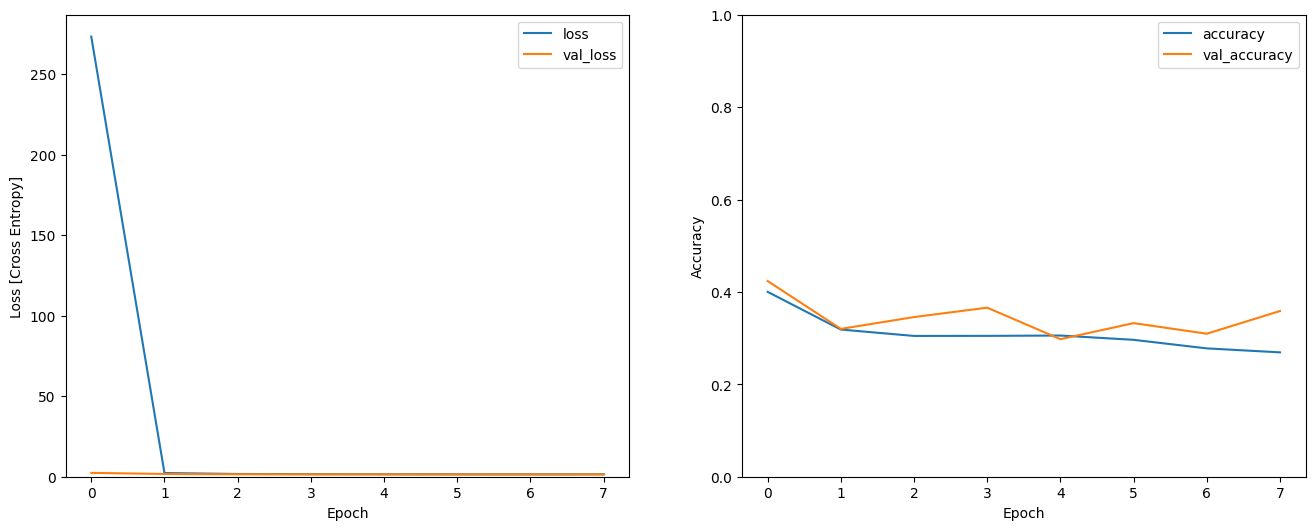

In [9]:
metrics = history.history
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [Cross Entropy]')

plt.subplot(1, 2, 2)
plt.plot(history.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 1])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

In [10]:
test_ds = test_ds.batch(batch_size)
test_loss, test_acc = model.evaluate(test_ds, verbose=2)

print(f'Test set accuracy: {test_acc:.0%}')

26/26 - 7s - 269ms/step - accuracy: 0.3659 - loss: 1.4257
Test set accuracy: 37%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
